## Import libraries

In [426]:
import pickle

import pandas as pd
import numpy as np
import scanpy as sc
import squidpy as sq
from pathlib import Path
import torch
import pytorch_lightning as pl
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader
from torch_geometric.sampler import NeighborSampler

from vqniche.initializers.initialize import *
from vqniche import metrics
from vqniche.utils.type_conversions import *
from vqniche.plotting import *
from vqniche.utils.loss_utils import aggregate_1hop_neighbor_features
from vqniche.utils.mask import set_mask_indices
from vqniche.utils import collect_test_configs

## Retrieve model output AnnData

In [2]:
adata_tmp = sc.read_h5ad('/nfs/team361/am84/VQNiche/xhk1020-CV1-CV2-5b_1p_code-activation-score.h5ad')

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
len(adata_tmp.obs['SQUINT_token'].unique())

780

In [4]:
adata_tmp_batch = adata_tmp[adata_tmp.obs['batch'] == 'Core2']

In [9]:
len(adata_tmp_batch.obs['SQUINT_token'].unique())

407

In [5]:
adata_tmp_batch

View of AnnData object with n_obs × n_vars = 71118 × 4949
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'grade', 'clinical_risk', 'patient', 'n_genes', 'original_cell_id', 'top5_1nbr_code-activation-score', 'SQUINT_token'
    obsm: 'spatial'

In [7]:
sc.pp.highly_variable_genes(
            adata_tmp_batch,
            flavor='seurat_v3',
            n_top_genes=1000,
            subset=True
        )

/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:172: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


In [8]:
# Define ground truth genes upregulated in scRNA-seq data of ccRCC macrophages post-ICB
genes = [
    "VSIG4",
    "CXCL9",
    "FCGR1A",
    "CXCL10",
    "CD163",
    "CLEC12A",
    "SLAMF8",
    "SCIMP",
    "PTAFR",
    "ADAMDEC1",
    "FBP1",
    "MARCO"
]

hvg_icb_genes = [gene for gene in genes if gene in adata_tmp_batch.var.index.tolist()]

/tmp/ipykernel_1107252/1257284105.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_tmp_batch,


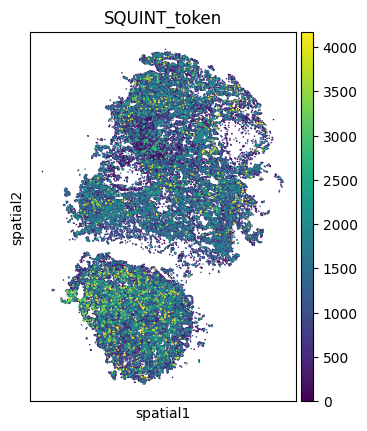

In [10]:
sc.pl.spatial(adata_tmp_batch,
              color='SQUINT_token',
              spot_size=30)

## Retrieve second model output AnnData

In [12]:
file_path = '/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250918_210610-18vudyiz/results/epoch=0-train_pearson_1hop_nbr=0.92/predict_adata.pkl'

with open(file_path, "rb") as f:
    adata = pickle.load(f)

In [13]:
# Also load original AnnData
orig_adata_list = []
dir_path = Path("/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/xhk1020-CV1-CV2-5b_1p")
for fname in list(dir_path.glob('**/*.h5ad')):
    print(fname)
    orig_adata_list.append(sc.read_h5ad(fname))
orig_adata_list_ordered = [orig_adata_list[2]] + [orig_adata_list[0]] + [orig_adata_list[3]] + [orig_adata_list[1]] + [orig_adata_list[4]]
orig_adata = sc.concat(orig_adata_list_ordered)
orig_adata

/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/xhk1020-CV1-CV2-5b_1p/adata_batch1.h5ad
/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/xhk1020-CV1-CV2-5b_1p/adata_batch3.h5ad
/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/xhk1020-CV1-CV2-5b_1p/adata_batch0.h5ad
/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/xhk1020-CV1-CV2-5b_1p/adata_batch2.h5ad
/lustre/scratch126/cellgen/lotfollahi/DATASETS/silver/xhk1020-CV1-CV2-5b_1p/adata_batch4.h5ad


/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 260193 × 4949
    obs: 'batch', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'grade', 'clinical_risk', 'patient', 'n_genes', 'original_cell_id'
    obsm: 'spatial'

/tmp/ipykernel_1107252/2900406863.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_batch,
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


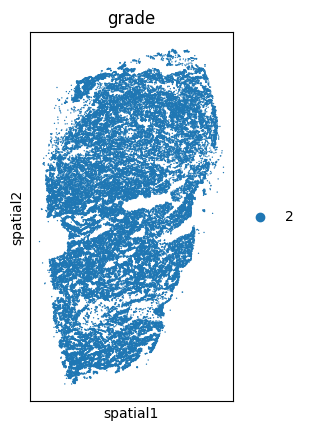

58432


/tmp/ipykernel_1107252/2900406863.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_batch,
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


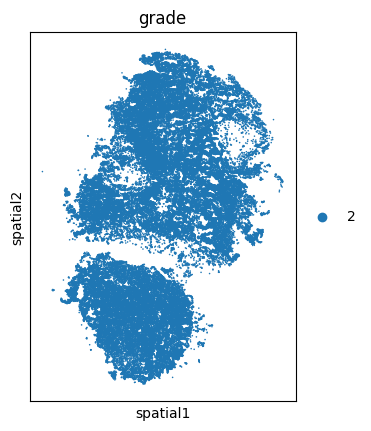

71118


/tmp/ipykernel_1107252/2900406863.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_batch,
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


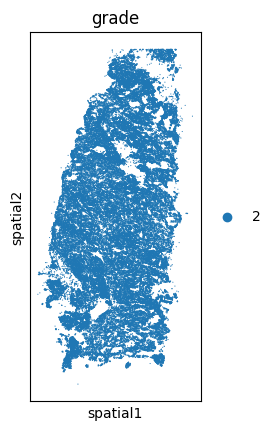

77314


/tmp/ipykernel_1107252/2900406863.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_batch,
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


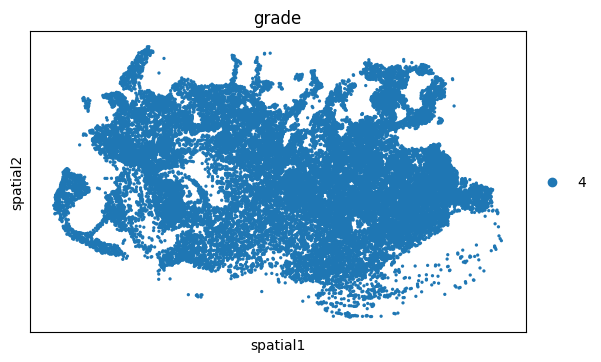

26026


/tmp/ipykernel_1107252/2900406863.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_batch,
/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/scanpy/plotting/_utils.py:481: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


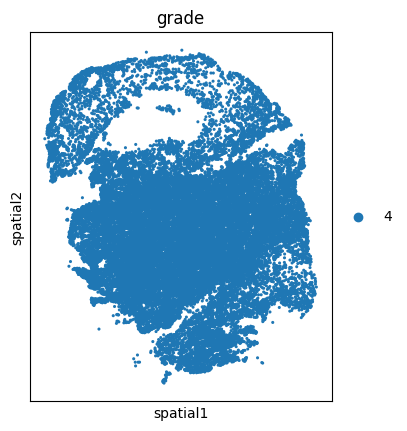

27303


In [14]:
for batch in orig_adata.obs['batch'].unique().tolist():
    adata_batch = orig_adata[orig_adata.obs['batch'] == batch]
    sc.pl.spatial(adata_batch,
                  color='grade',
                  spot_size=30)
    print(len(adata_batch))

# batch0, Core 1: CV1-KID-0-FT-1
# batch1, Core 2: CV1-KID-0-FT-2 <-- sample of interest
# batch2, Core 3: CV1-KID-0-FT-3
# batch3, Core 4: CV2-KID-0-FT-1-s2
# batch4, Core 5: CV2-KID-0-FT-2

In [15]:
mapping = {}
for orig_a in orig_adata_list:
    for i in adata.obs['adata_batch_ids'].unique():
        pred_a = adata[adata.obs['adata_batch_ids']==i]
        if orig_a.shape[0] == pred_a.shape[0]:
            mapping[orig_a.obs['batch'].unique().tolist()[0]] = i

In [16]:
mapping

{'Core2': 1, 'Core4': 3, 'Core1': 0, 'Core3': 2, 'Core5': 4}

In [17]:
# Add cell IDs from original AnnData
adata.obs['cell_id'] = orig_adata.obs['original_cell_id'].values.tolist()

## Load annotated AnnData object from MintFlow

71104


/tmp/ipykernel_1107252/2728748499.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_annot,


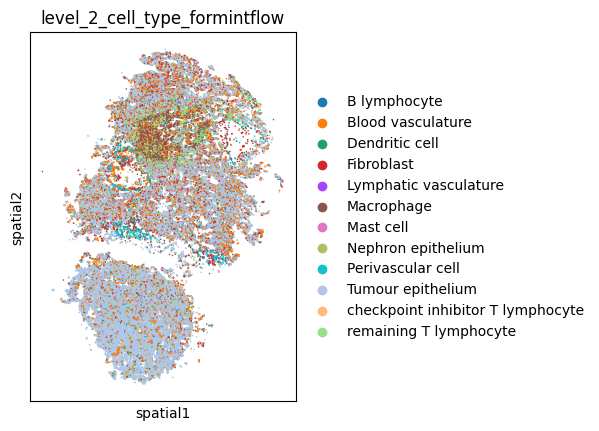

In [18]:
# Load annotated AnnData object from MintFlow
adata_annot = sc.read_h5ad('/nfs/team361/aa36/OnGit/inflow-reproducibility/Analysis/42_Kidney_Rerun_NewSubPopulation/NonGit/Data/inflow_testdata_RCC3_processed_5K.h5ad')

print(len(adata_annot))
sc.pl.spatial(adata_annot,
              color='level_2_cell_type_formintflow',
              spot_size=30)

In [19]:
adata_annot.obs['cell_id'] = adata_annot.obs['cell_id'].astype(str)

## Process & Combine AnnData objects

In [20]:
# Find all unique tokens
unique_tokens, token_ids = np.unique(adata.obsm['H_quantized'], axis=0, return_inverse=True)

# token_ids gives the discrete code index for each row
adata.obs['code'] = token_ids

In [21]:
len(adata.obs['code'].unique())

741

In [22]:
# Filter for MintFlow sample
adata_batch_squint = adata[adata.obs['adata_batch_ids'] == 1]

In [23]:
adata_batch_squint

View of AnnData object with n_obs × n_vars = 71118 × 1000
    obs: 'clinical_risk', 'grade', 'adata_batch_ids', 'cell_id', 'code'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'

In [24]:
# Add gene names
adata_batch_squint.var.index = adata_tmp_batch.var.index

/tmp/ipykernel_1107252/2277826187.py:2: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  adata_batch_squint.var.index = adata_tmp_batch.var.index


In [26]:
len(adata_batch_squint.obs['code'].unique())

285

In [27]:
# Add cell type annotations
adata_batch_squint.obs = adata_batch_squint.obs.merge(
    adata_annot.obs[['cell_id', 'level_2_cell_type_formintflow']],
    on='cell_id',
    how='left'
)

/tmp/ipykernel_1107252/3747240447.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_batch_squint,


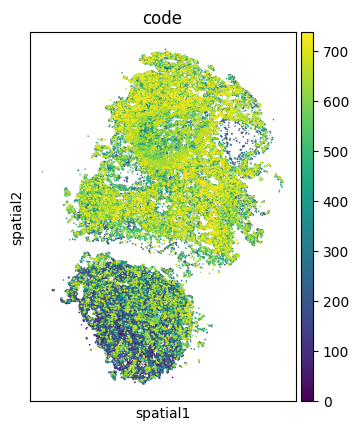

In [28]:
sc.pl.spatial(adata_batch_squint,
              color='code',
              spot_size=30)

/tmp/ipykernel_1107252/3775878095.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_batch_squint,


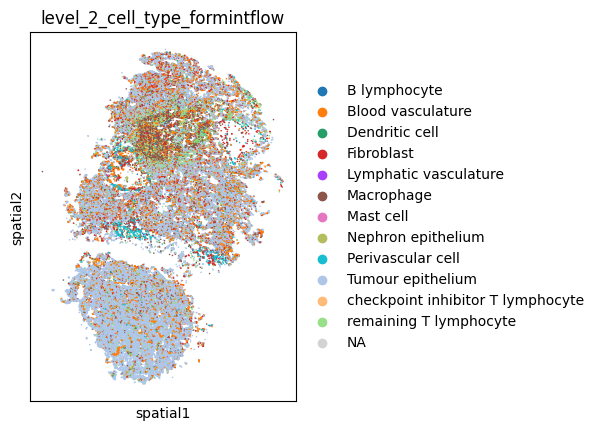

In [29]:
sc.pl.spatial(adata_batch_squint,
              color='level_2_cell_type_formintflow',
              spot_size=30)

In [30]:
adata_batch_squint.obs['level_2_cell_type_formintflow'].unique().tolist()

['Macrophage',
 'Tumour epithelium',
 'Fibroblast',
 'remaining T lymphocyte',
 'Blood vasculature',
 'checkpoint inhibitor T lymphocyte',
 'B lymphocyte',
 'Perivascular cell',
 'Mast cell',
 'Dendritic cell',
 'Nephron epithelium',
 nan,
 'Lymphatic vasculature']

## Perform perturbation

In [31]:
# Create cell state masks
mask_tcell = adata_batch_squint.obs['level_2_cell_type_formintflow'] == 'remaining T lymphocyte'
mask_tcell_icb = adata_batch_squint.obs['level_2_cell_type_formintflow'] == 'checkpoint inhibitor T lymphocyte'

# Extract candidate pool from target cell state
X_icb_pool = adata_batch_squint.X[mask_tcell_icb]

# Randomly sample from pool for each replaced cell
n_tcell = mask_tcell.sum()
random_indices = np.random.choice(len(X_icb_pool), size=n_tcell, replace=True)

# Replace quantized values
adata_batch_squint.layers['X_perturbed'] = adata_batch_squint.X.copy()
adata_batch_squint.layers['X_perturbed'][mask_tcell] = X_icb_pool[random_indices]

In [32]:
adata_batch_squint.layers['X_perturbed'].sum()

23305130.0

In [33]:
adata_batch_squint.X.sum()

23285278.0

In [92]:
adata_batch_squint.X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 2., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [86]:
adata_batch_squint

AnnData object with n_obs × n_vars = 71118 × 1000
    obs: 'clinical_risk', 'grade', 'adata_batch_ids', 'cell_id', 'code', 'level_2_cell_type_formintflow', 'macrophage_roi_mask', 'tcell_roi_mask', 'SQUINT_token', 'SQUINT_token_perturbed'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads', 'level_2_cell_type_formintflow_colors', 'macrophage_roi_mask_colors', 'tcell_roi_mask_colors', 'SQUINT_token_colors', 'SQUINT_token_perturbed_colors'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'
    layers: 'X_perturbed'

In [87]:
data_batch

DataBatch(y_grade=[71118, 2], y_clinical_risk=[71118, 2], xy_coordinates=[71118, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[71118, 1000], y=[71118, 2], edge_index=[2, 729618], encoder_condition_dim=0, spatial_prior_feature_dim=0, attr_decoder_condition_dim=0, adj_decoder_condition_dim=0, num_features=1000, num_classes=2, num_nodes=71118, num_edges=[1], train_mask=[71118], val_mask=[71118], test_mask=[71118], batch=[71118], ptr=[2], adata_batch_ids=[71118])

In [85]:
data_batch.x.sum()

tensor(23285326.)

In [106]:
adata_batch_squint.X.sum()

23285278.0

In [109]:
adata_batch_squint.X.sum()

23285278.0

In [111]:
torch.tensor(adata_batch_squint.X)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 2.,  ..., 0., 1., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [110]:
torch.tensor(adata_batch_squint.X).sum()

tensor(23285326.)

In [107]:
data_batch.x.sum()

tensor(23285326.)

In [35]:
macrophage_roi_mask = (adata_batch_squint.obsm['spatial'][:, 0] > 1500) &  (adata_batch_squint.obsm['spatial'][:, 0] < 3500) &\
(adata_batch_squint.obsm['spatial'][:, 1] > 1000) &  (adata_batch_squint.obsm['spatial'][:, 1] < 2500) &\
(adata_batch_squint.obs['level_2_cell_type_formintflow'] == 'Macrophage').values

In [36]:
tcell_roi_mask = (adata_batch_squint.obsm['spatial'][:, 0] > 1500) &  (adata_batch_squint.obsm['spatial'][:, 0] < 3500) &\
(adata_batch_squint.obsm['spatial'][:, 1] > 1000) &  (adata_batch_squint.obsm['spatial'][:, 1] < 2500) &\
(adata_batch_squint.obs['level_2_cell_type_formintflow'] == 'remaining T lymphocyte').values

In [39]:
adata_batch_squint.obs['macrophage_roi_mask'] = macrophage_roi_mask
adata_batch_squint.obs['tcell_roi_mask'] = tcell_roi_mask

/tmp/ipykernel_1107252/1825164084.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_batch_squint,


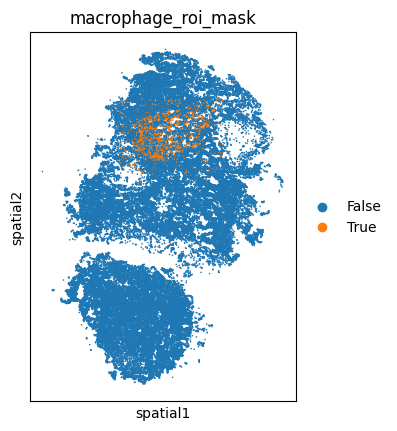

/tmp/ipykernel_1107252/1825164084.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_batch_squint,


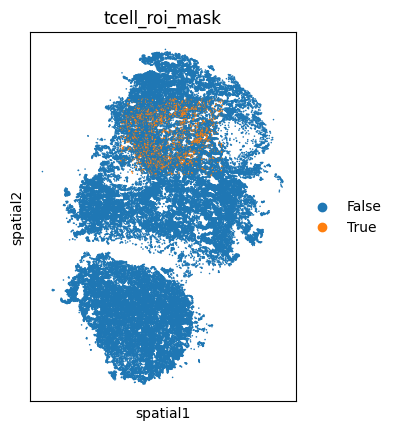

In [40]:
sc.pl.spatial(adata_batch_squint,
              color='macrophage_roi_mask',
              spot_size=30)

sc.pl.spatial(adata_batch_squint,
              color='tcell_roi_mask',
              spot_size=30)

In [41]:
adata_region_squint = adata_batch_squint[
    (adata_batch_squint.obsm['spatial'][:, 0] > 1500) &  (adata_batch_squint.obsm['spatial'][:, 0] < 3500) &\
    (adata_batch_squint.obsm['spatial'][:, 1] > 1000) &  (adata_batch_squint.obsm['spatial'][:, 1] < 2500)
].copy()
print(adata_region_squint)

AnnData object with n_obs × n_vars = 16879 × 1000
    obs: 'clinical_risk', 'grade', 'adata_batch_ids', 'cell_id', 'code', 'level_2_cell_type_formintflow', 'macrophage_roi_mask', 'tcell_roi_mask'
    uns: 'X', 'X_nbr', 'edge_index', 'Indices', 'X_hat', 'X_hat_nbr', 'Logits', 'codebook_size', 'separate', 'num_heads', 'level_2_cell_type_formintflow_colors', 'macrophage_roi_mask_colors', 'tcell_roi_mask_colors'
    obsm: 'spatial', 'H_latent', 'H_quantized', 'H_adj'
    layers: 'X_perturbed'


/software/cellgen/team361/am84/envs/vqniche-reproducibility/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


/tmp/ipykernel_1107252/1204050192.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_region_squint,


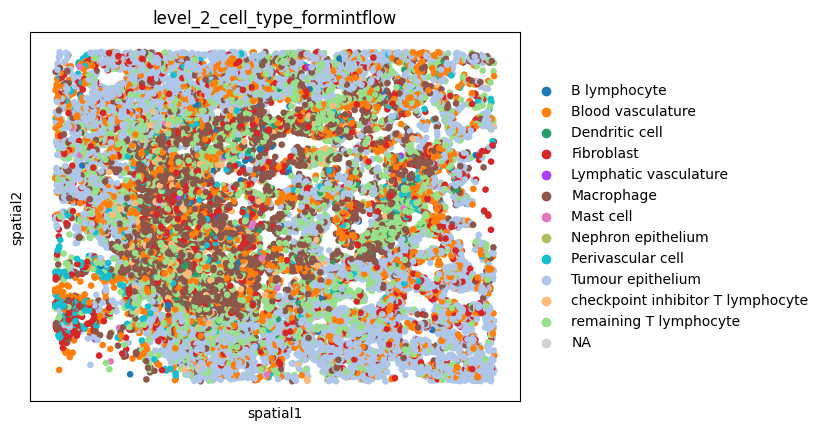

In [42]:
sc.pl.spatial(adata_region_squint,
              color='level_2_cell_type_formintflow',
              spot_size=30)

## Define model config

In [391]:
#wandb_run_dir = '/nfs/team361/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/run-20250923_150713-w9ednc8e' # bad cp with 200 codes
#wandb_run_dir = '/nfs/team361/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/run-20250923_150654-m2wmpcmu'
#wandb_run_dir = '/nfs/team361/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/run-20250923_143634-esi0hiwn' # bad cp with 20 codes
wandb_run_dir = '/nfs/team361/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/run-20250923_133833-56b55sj6' # good cp with 50 codes
#wandb_run_dir = '/nfs/team361/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/run-20250923_132308-giqk6exo' # bad cp with 200 codes, 1 epoch
#wandb_run_dir = '/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/run-20250923_104752-8w4od3hh' # bad cp with 200 codes and conditions
#wandb_run_dir = '/lustre/scratch126/cellgen/lotfollahi/am84/VQNiche/logs/xhk1020-CV1-CV2-5b_1p/standalone/VQNiche/batch=-1/spatial_n_neighs_8/wandb/offline-run-20250918_210610-18vudyiz'

## Run model without perturbation

In [392]:
# Get macrophage codes in ROI - without perturbation
config = collect_test_configs(wandb_run_dir = wandb_run_dir)
config['dataset']['adata_batch_idx'] = [1]

# --------------------- Determinism Settings ---------------------
pl.seed_everything(config['experiment']['seed'])

# --------------------- Dataset ---------------------
dataset_blob = initialize_dataset_blob(config)
with open(Path(dataset_blob.processed_dir) / 'label_categories.pkl', 'rb') as f:
    label_categories = pickle.load(f)

# --------------------- Databatch ---------------------
data_batch = initialize_databatch(
                config=config,
                dataset_blob=dataset_blob,
            )
data_batch.test_mask = torch.tensor(macrophage_roi_mask)

# build the data dictionary for the loader after data transforms
base_data = {
    'x': data_batch.x,
    'y': data_batch.y,
    'edge_index': data_batch.edge_index,
    'xy_coordinates': data_batch.xy_coordinates,
    'train_mask': data_batch.train_mask,
    'val_mask': data_batch.val_mask,
    'test_mask': data_batch.test_mask,
    'adata_batch_ids': data_batch.adata_batch_ids,
}

optional_data_keys = [
    # 'y_cell_types',
    # 'y_niche_types',
    'encoder_conditions',
    'spatial_prior_features',
    'attr_decoder_conditions',
    'adj_decoder_conditions',
]

data_dict_for_loader = {
    **base_data,
    **{attr: getattr(data_batch, attr) for attr in optional_data_keys if getattr(data_batch, attr, None) is not None}
}

data_for_loader = Data(**data_dict_for_loader)

# keep all other keys that start with 'y_'
for key in list(data_batch.keys()):
    if key.startswith('y_'):
        setattr(data_for_loader, key, data_batch[key])

test_sampler = NeighborSampler(
                data=data_for_loader,
                num_neighbors=[-1],
            )

test_loader = NeighborLoader(
                data=data_for_loader,
                num_workers=1,
                input_nodes=data_for_loader.test_mask,
                neighbor_sampler=test_sampler,
                shuffle=False,
                batch_size=64,
                num_neighbors=[-1],
            )

# --------------------- Model ---------------------
Model = set_model_class(config['model']['model_name'])
model = Model.load_from_checkpoint(
            config['model']['model_ckpt_fname'],
        )
model.eval()
print('Codebook size', model.encoder.vq.codebook_size)

# --------------------- Forward pass ---------------------
all_indices = []
all_xhat = []

for batch in test_loader:
    mask_idx: torch.LongTensor = set_mask_indices(
                N=batch.x.size(0),
                batch_size=batch.batch_size,
                mask_ratio=1,
            )
    
    masked_x = model.apply_mask_to_attributes(
                batch_x=batch.x,
                mask_idx=mask_idx,
            )

    h_latent, \
    h_quantized, \
    indices, \
    _ \
        = model.encoder(
                        masked_x.to(model.device),
                        batch.edge_index.to(model.device),
                        #batch.encoder_conditions.to(model.device),
                    )

    all_indices.append(indices[:batch.batch_size].detach().cpu())

    xhat = model.attribute_decoder(
        x=h_quantized[:batch.batch_size],
        read_depth=batch.x.sum(1)[:batch.batch_size].to(model.device),
        #conditions=batch.attr_decoder_conditions[:batch.batch_size].to(model.device)
    )

    all_xhat.append(xhat.detach().cpu())

all_indices_tmp = torch.cat(all_indices, dim=0)
all_xhat_tmp = torch.cat(all_xhat, dim=0)

Seed set to 0


Best checkpoint found: epoch=2-train_pearson_1hop_nbr=0.84.ckpt
SubsetHVG: Subsetted data to 1000 features.
DataBatch(y_grade=[71118, 2], y_clinical_risk=[71118, 2], xy_coordinates=[71118, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[71118, 1000], y=[71118, 2], edge_index=[2, 729618], encoder_condition_dim=0, spatial_prior_feature_dim=0, attr_decoder_condition_dim=0, adj_decoder_condition_dim=0, num_features=1000, num_classes=2, num_nodes=71118, num_edges=[1], train_mask=[71118], val_mask=[71118], test_mask=[71118], batch=[71118], ptr=[2], adata_batch_ids=[71118])
Batch ID(s): [1]
Data Batch: DataBatch(y_grade=[71118, 2], y_clinical_risk=[71118, 2], xy_coordinates=[71118, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[71118, 1000], y=[71118, 2], edge_index=[2, 729618], encoder_condition_dim=0, spatial_prior_feature_dim=0, attr_decoder_condition_dim=0, adj_decoder_condition_dim=0, num_features=1000, num_classes=2, num

In [393]:
# Add tokens to AnnData object
mask = adata_batch_squint.obs['macrophage_roi_mask'].to_numpy()
values = all_indices_tmp.detach().cpu().numpy().astype(float)  # ensure float so NaN works

# Initialize with NaNs
result = np.full(mask.shape[0], np.nan, dtype=float)

# Fill positions where mask is True
result[mask] = values

# Store in obs
adata_batch_squint.obs['SQUINT_token'] = pd.Categorical(result)

# Start from numeric tokens (with NaNs allowed)
tokens = adata_batch_squint.obs["SQUINT_token"].astype(float)

# Count cells per category (ignores NaN automatically)
counts = tokens.value_counts()

# Categories with <10 cells
small_cats = counts[counts < 10].index

# Replace small categories with NaN
tokens = tokens.where(~tokens.isin(small_cats), np.nan)

# Store back as categorical
adata_batch_squint.obs["SQUINT_token"] = pd.Categorical(tokens)

In [394]:
adata_batch_squint.obs["SQUINT_token"].unique()

[NaN, 49.0, 29.0, 44.0, 8.0, 4.0, 48.0, 30.0, 18.0]
Categories (8, float64): [4.0, 8.0, 18.0, 29.0, 30.0, 44.0, 48.0, 49.0]

In [395]:
counts

SQUINT_token
29.0    1879
44.0     506
49.0     286
8.0      101
4.0       61
48.0      30
18.0      18
30.0      15
12.0       9
1.0        4
13.0       2
42.0       2
0.0        2
34.0       2
9.0        1
35.0       1
25.0       1
2.0        1
Name: count, dtype: int64

In [396]:
adata_batch_squint.obs["SQUINT_token"]

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
71113   NaN
71114   NaN
71115   NaN
71116   NaN
71117   NaN
Name: SQUINT_token, Length: 71118, dtype: category
Categories (8, float64): [4.0, 8.0, 18.0, 29.0, 30.0, 44.0, 48.0, 49.0]

In [397]:
unique_tokens = adata_batch_squint.obs["SQUINT_token"].unique()

In [398]:
unique_tokens

[NaN, 49.0, 29.0, 44.0, 8.0, 4.0, 48.0, 30.0, 18.0]
Categories (8, float64): [4.0, 8.0, 18.0, 29.0, 30.0, 44.0, 48.0, 49.0]

In [416]:
adata_batch_squint.uns['edge_index'].shape

torch.Size([2, 2673293])

In [419]:
adata_batch_squint.uns['edge_index']

tensor([[     0,      0,      0,  ..., 260192, 260192, 260192],
        [     0,  46604,  45100,  ..., 259929, 259928, 259908]])

In [427]:
# Add spatial neighbor graph
n_neighs = 8
radius = None
spatial_key = 'spatial'
include_self_loop = True
coord_type = 'generic'
key_added = 'spatial'

sq.gr.spatial_neighbors(
    adata=adata_batch_squint,
    coord_type=coord_type,
    spatial_key=spatial_key,
    delaunay=False,
    n_neighs=n_neighs,
    radius=radius,
    set_diag=include_self_loop,
    key_added=key_added,
)

In [507]:
# Flag macrophages with T-cell neighbors
A = adata_batch_squint.obsp["spatial_connectivities"]

t_mask = adata_batch_squint.obs["tcell_roi_mask"].to_numpy()
m_mask = adata_batch_squint.obs["macrophage_roi_mask"].to_numpy()

# 1. For each cell, check if it has a T-cell neighbor
# Multiply adjacency matrix by the boolean T-cell mask (cast to int)
neighbors_with_t = (A @ t_mask.astype(int)) > 0   # True if ≥1 T-cell neighbor

# 2. Restrict to macrophages
m_with_t_neighbors = m_mask & neighbors_with_t

# 3. Save back to obs
adata_batch_squint.obs["macrophage_with_tcell_neighbors"] = m_with_t_neighbors

In [508]:
adata_batch_squint.obs["macrophage_roi_mask"].sum()

2921

In [509]:
adata_batch_squint.obs["macrophage_with_tcell_neighbors"].sum()

2404

/tmp/ipykernel_1107252/4222434739.py:8: FutureWarning:

Use `squidpy.pl.spatial_scatter` instead.



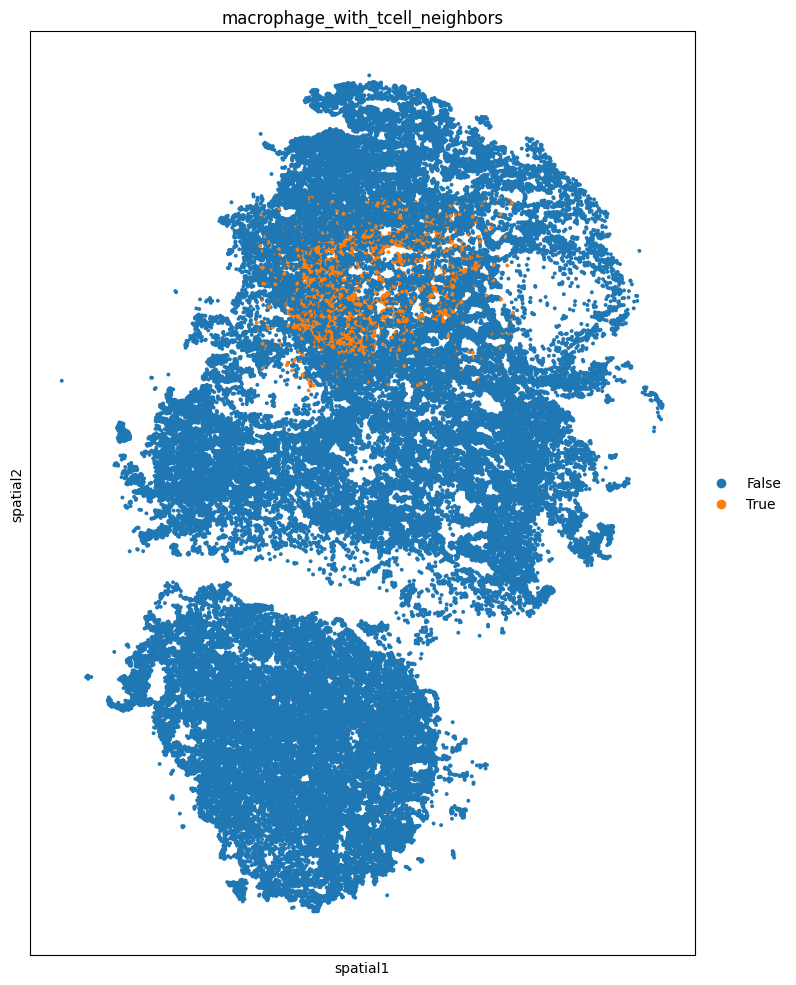

In [510]:
# Visualize tokens
plt.rcParams["figure.figsize"] = (12, 12)
try:
    del(adata_batch_squint.uns['macrophage_with_tcell_neighbors'])
except:
    pass

sc.pl.spatial(adata_batch_squint,
              color='macrophage_with_tcell_neighbors',
              spot_size=30)

/tmp/ipykernel_1107252/3298077949.py:8: FutureWarning:

Use `squidpy.pl.spatial_scatter` instead.



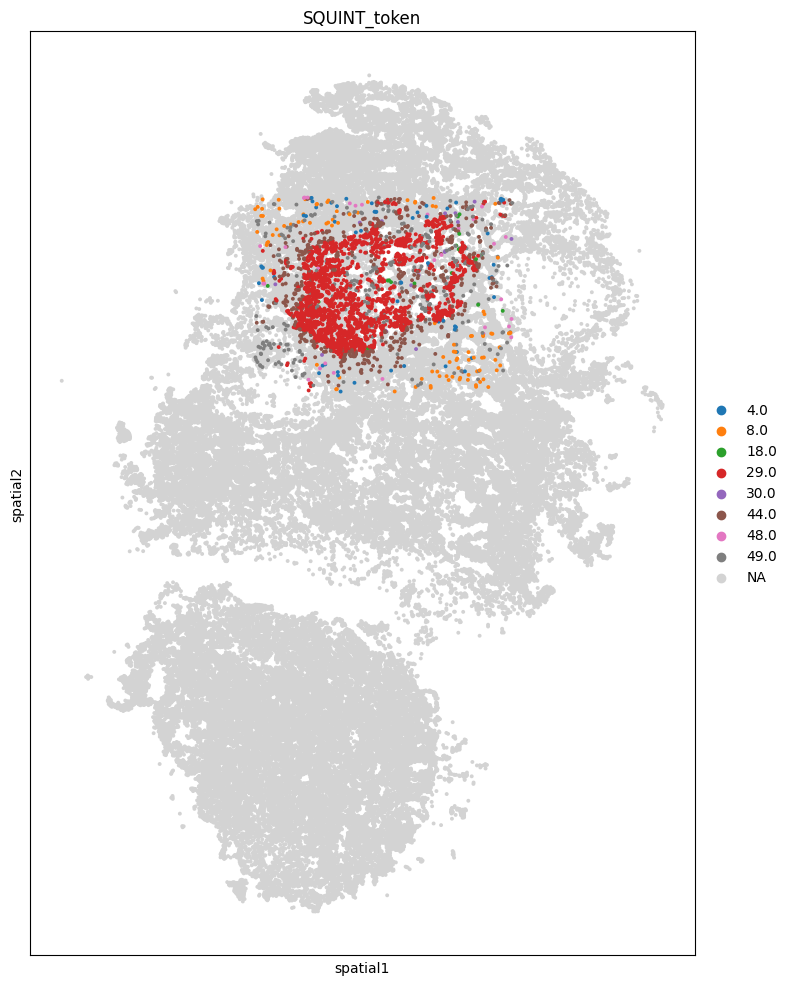

In [511]:
# Visualize tokens
plt.rcParams["figure.figsize"] = (12, 12)
try:
    del(adata_batch_squint.uns['SQUINT_token_colors'])
except:
    pass

sc.pl.spatial(adata_batch_squint,
              color='SQUINT_token',
              spot_size=30)

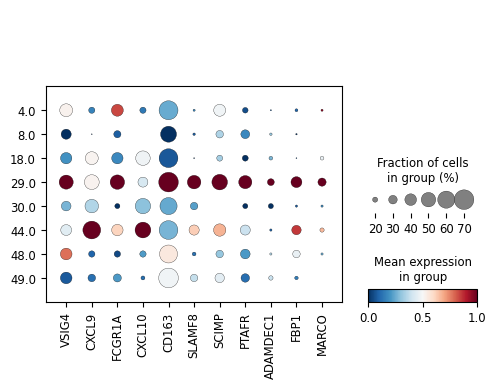

In [512]:
# Visualize gene expression dotplot per token
sc.pl.dotplot(
    adata_batch_squint,
    var_names=hvg_icb_genes,
    groupby="SQUINT_token",
    standard_scale="var",   # scales per gene (optional, for better comparability)
    dot_max=0.7,            # max dot size
    dot_min=0.1,            # min dot size
    color_map="RdBu_r"      # diverging colormap
)

In [513]:
new_tokens = adata_batch_squint.obs["SQUINT_token"].copy()

# Replace with NaN where macrophage_with_gt2_tcell_neighbors is False
new_tokens.loc[~adata_batch_squint.obs["macrophage_with_tcell_neighbors"]] = np.nan

# Store in obs as categorical
adata_batch_squint.obs["SQUINT_token_tcellneigh"] = pd.Categorical(new_tokens)

/tmp/ipykernel_1107252/3782224334.py:8: FutureWarning:

Use `squidpy.pl.spatial_scatter` instead.



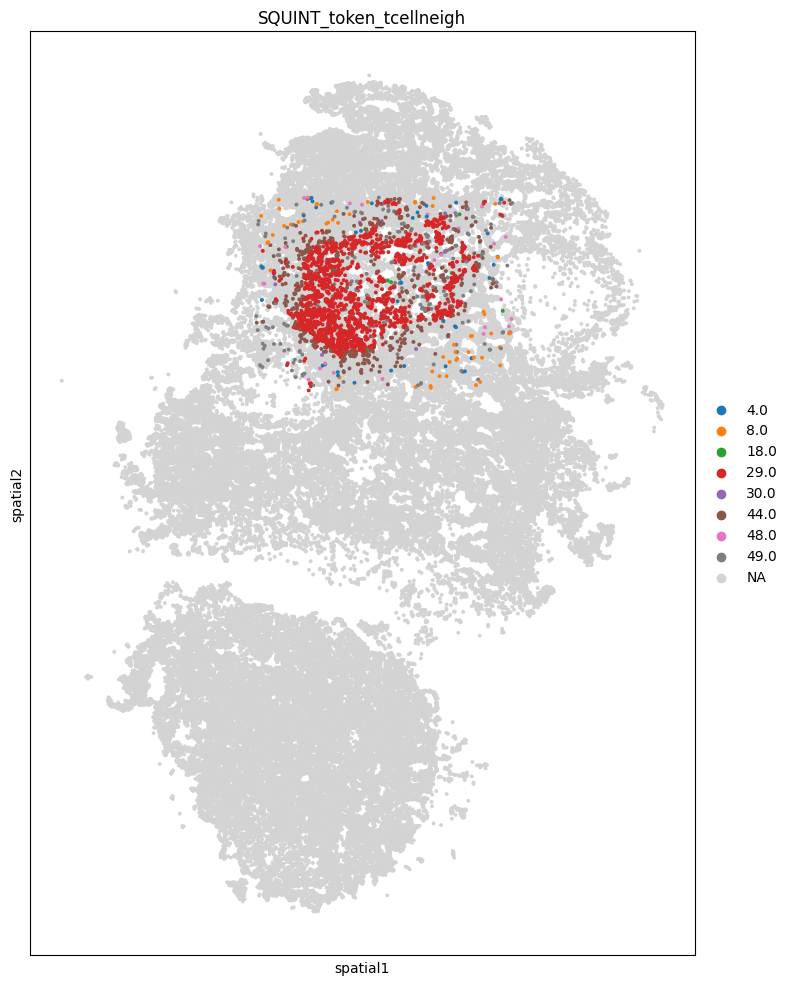

In [514]:
# Visualize tokens
plt.rcParams["figure.figsize"] = (12, 12)
try:
    del(adata_batch_squint.uns['SQUINT_token_tcellneigh'])
except:
    pass

sc.pl.spatial(adata_batch_squint,
              color='SQUINT_token_tcellneigh',
              spot_size=30)

In [515]:
adata_batch_squint.obs["SQUINT_token_tcellneigh"] = (
    adata_batch_squint.obs["SQUINT_token_tcellneigh"]
    .cat.remove_unused_categories()
)

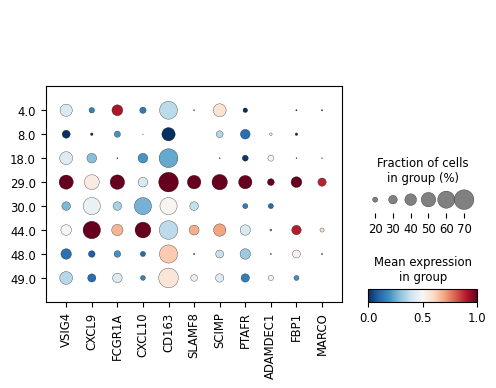

In [516]:
# Visualize gene expression dotplot per token
sc.pl.dotplot(
    adata_batch_squint,
    var_names=hvg_icb_genes,
    groupby="SQUINT_token_tcellneigh",
    standard_scale="var",   # scales per gene (optional, for better comparability)
    dot_max=0.7,            # max dot size
    dot_min=0.1,            # min dot size
    color_map="RdBu_r"      # diverging colormap
)

## Run model with perturbation

In [517]:
config = collect_test_configs(wandb_run_dir = wandb_run_dir)
config['dataset']['adata_batch_idx'] = [1]

# --------------------- Determinism Settings ---------------------
pl.seed_everything(config['experiment']['seed'])

# --------------------- Dataset ---------------------
dataset_blob = initialize_dataset_blob(config)
with open(Path(dataset_blob.processed_dir) / 'label_categories.pkl', 'rb') as f:
    label_categories = pickle.load(f)

# --------------------- Databatch ---------------------
data_batch = initialize_databatch(
                config=config,
                dataset_blob=dataset_blob,
            )
data_batch.test_mask = torch.tensor(macrophage_roi_mask)

# build the data dictionary for the loader after data transforms
base_data = {
    'x': torch.tensor(adata_batch_squint.layers['X_perturbed']), # data_batch.x,
    'y': data_batch.y,
    'edge_index': data_batch.edge_index,
    'xy_coordinates': data_batch.xy_coordinates,
    'train_mask': data_batch.train_mask,
    'val_mask': data_batch.val_mask,
    'test_mask': data_batch.test_mask,
    'adata_batch_ids': data_batch.adata_batch_ids,
}

optional_data_keys = [
    # 'y_cell_types',
    # 'y_niche_types',
    'encoder_conditions',
    'spatial_prior_features',
    'attr_decoder_conditions',
    'adj_decoder_conditions',
]

data_dict_for_loader = {
    **base_data,
    **{attr: getattr(data_batch, attr) for attr in optional_data_keys if getattr(data_batch, attr, None) is not None}
}

data_for_loader = Data(**data_dict_for_loader)

# keep all other keys that start with 'y_'
for key in list(data_batch.keys()):
    if key.startswith('y_'):
        setattr(data_for_loader, key, data_batch[key])

test_sampler = NeighborSampler(
                data=data_for_loader,
                num_neighbors=[-1],
            )

test_loader = NeighborLoader(
                data=data_for_loader,
                num_workers=1,
                input_nodes=data_for_loader.test_mask,
                neighbor_sampler=test_sampler,
                shuffle=False,
                batch_size=64,
                num_neighbors=[-1],
            )

# --------------------- Model ---------------------
Model = set_model_class(config['model']['model_name'])
model = Model.load_from_checkpoint(
            config['model']['model_ckpt_fname'],
        )
model.eval()
print('Codebook size', model.encoder.vq.codebook_size)

# --------------------- Forward pass ---------------------
all_indices = []
all_xhat = []

for batch in test_loader:
    mask_idx: torch.LongTensor = set_mask_indices(
                N=batch.x.size(0),
                batch_size=batch.batch_size,
                mask_ratio=1,
            )
    
    masked_x = model.apply_mask_to_attributes(
                batch_x=batch.x,
                mask_idx=mask_idx,
            )

    h_latent, \
    h_quantized, \
    indices, \
    _ \
        = model.encoder(
                        masked_x.to(model.device),
                        batch.edge_index.to(model.device),
                        #batch.encoder_conditions.to(model.device),
                    )

    all_indices.append(indices[:batch.batch_size].detach().cpu())

    xhat = model.attribute_decoder(
        x=h_quantized[:batch.batch_size],
        read_depth=batch.x.sum(1)[:batch.batch_size].to(model.device),
        #conditions=batch.attr_decoder_conditions[:batch.batch_size].to(model.device)
    )

    all_xhat.append(xhat.detach().cpu())

all_indices_tmp = torch.cat(all_indices, dim=0)
all_xhat_tmp = torch.cat(all_xhat, dim=0)

Seed set to 0


Best checkpoint found: epoch=2-train_pearson_1hop_nbr=0.84.ckpt
SubsetHVG: Subsetted data to 1000 features.
DataBatch(y_grade=[71118, 2], y_clinical_risk=[71118, 2], xy_coordinates=[71118, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[71118, 1000], y=[71118, 2], edge_index=[2, 729618], encoder_condition_dim=0, spatial_prior_feature_dim=0, attr_decoder_condition_dim=0, adj_decoder_condition_dim=0, num_features=1000, num_classes=2, num_nodes=71118, num_edges=[1], train_mask=[71118], val_mask=[71118], test_mask=[71118], batch=[71118], ptr=[2], adata_batch_ids=[71118])
Batch ID(s): [1]
Data Batch: DataBatch(y_grade=[71118, 2], y_clinical_risk=[71118, 2], xy_coordinates=[71118, 2], cell_id=[1], dataset_id=[1], tissue=[1], species=[1], adata_batch_id=[1], x=[71118, 1000], y=[71118, 2], edge_index=[2, 729618], encoder_condition_dim=0, spatial_prior_feature_dim=0, attr_decoder_condition_dim=0, adj_decoder_condition_dim=0, num_features=1000, num_classes=2, num

In [518]:
# Add tokens to AnnData object
mask = adata_batch_squint.obs['macrophage_roi_mask'].to_numpy()
values = all_indices_tmp.detach().cpu().numpy().astype(float)  # ensure float so NaN works

# Initialize with NaNs
result = np.full(mask.shape[0], np.nan, dtype=float)

# Fill positions where mask is True
result[mask] = values

# Store in obs
adata_batch_squint.obs['SQUINT_token_perturbed'] = pd.Categorical(result)

# Get counts per category
counts = adata_batch_squint.obs["SQUINT_token_perturbed"].value_counts()

# Categories with <10 cells
small_cats = counts[counts < 10].index

# Convert to object to allow NaNs
squint_col = adata_batch_squint.obs["SQUINT_token_perturbed"].astype(str)

# Replace small categories with NaN
squint_col = squint_col.where(~squint_col.isin(small_cats.astype(str)), np.nan)

# Save back and recast as categorical
adata_batch_squint.obs["SQUINT_token_perturbed"] = squint_col.astype("category")


In [519]:
unique_tokens_perturbed = adata_batch_squint.obs["SQUINT_token_perturbed"].unique()

In [520]:
unique_tokens_perturbed

['nan', '49.0', '29.0', '44.0', '8.0', '4.0', NaN, '48.0', '18.0', '30.0']
Categories (9, object): ['18.0', '29.0', '30.0', '4.0', ..., '48.0', '49.0', '8.0', 'nan']

/tmp/ipykernel_1107252/2089814541.py:8: FutureWarning:

Use `squidpy.pl.spatial_scatter` instead.



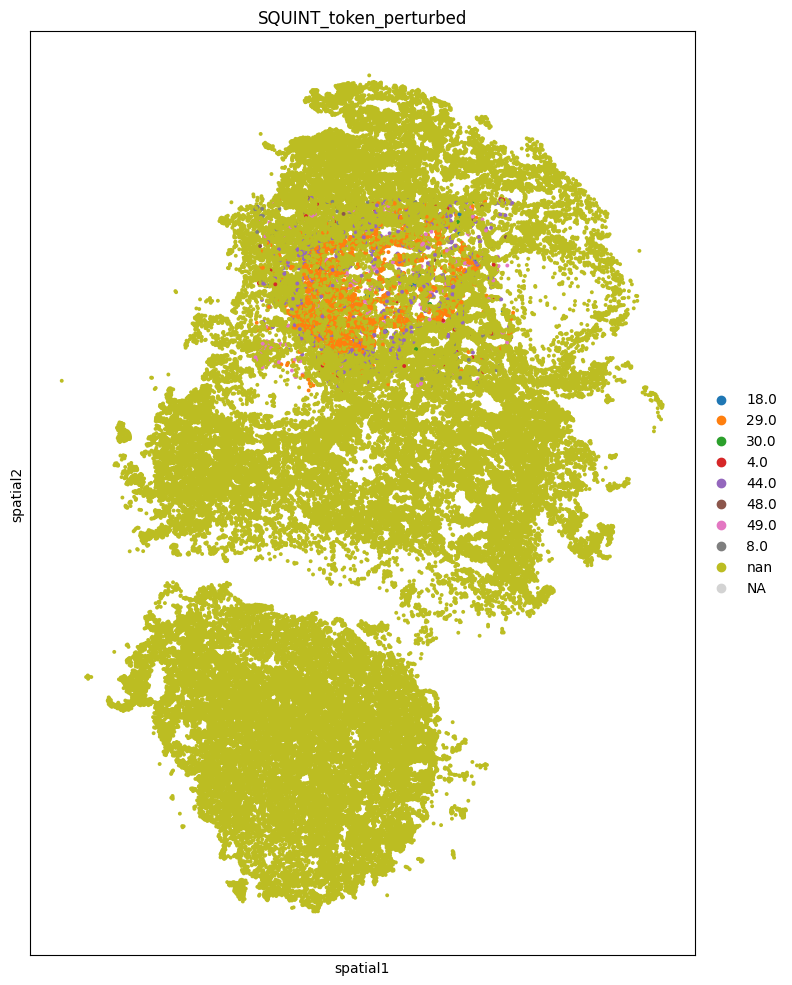

In [521]:
# Visualize tokens
plt.rcParams["figure.figsize"] = (12, 12)
try:
    del(adata_batch_squint.uns['SQUINT_token_perturbed_colors'])
except:
    pass

sc.pl.spatial(adata_batch_squint,
              color='SQUINT_token_perturbed',
              spot_size=30)

In [522]:
new_tokens = adata_batch_squint.obs["SQUINT_token_perturbed"].copy()

# Replace with NaN where macrophage_with_gt2_tcell_neighbors is False
new_tokens.loc[~adata_batch_squint.obs["macrophage_with_tcell_neighbors"]] = np.nan

# Store in obs as categorical
adata_batch_squint.obs["SQUINT_token_perturbed_tcellneigh"] = pd.Categorical(new_tokens)

/tmp/ipykernel_1107252/3791112366.py:8: FutureWarning:

Use `squidpy.pl.spatial_scatter` instead.



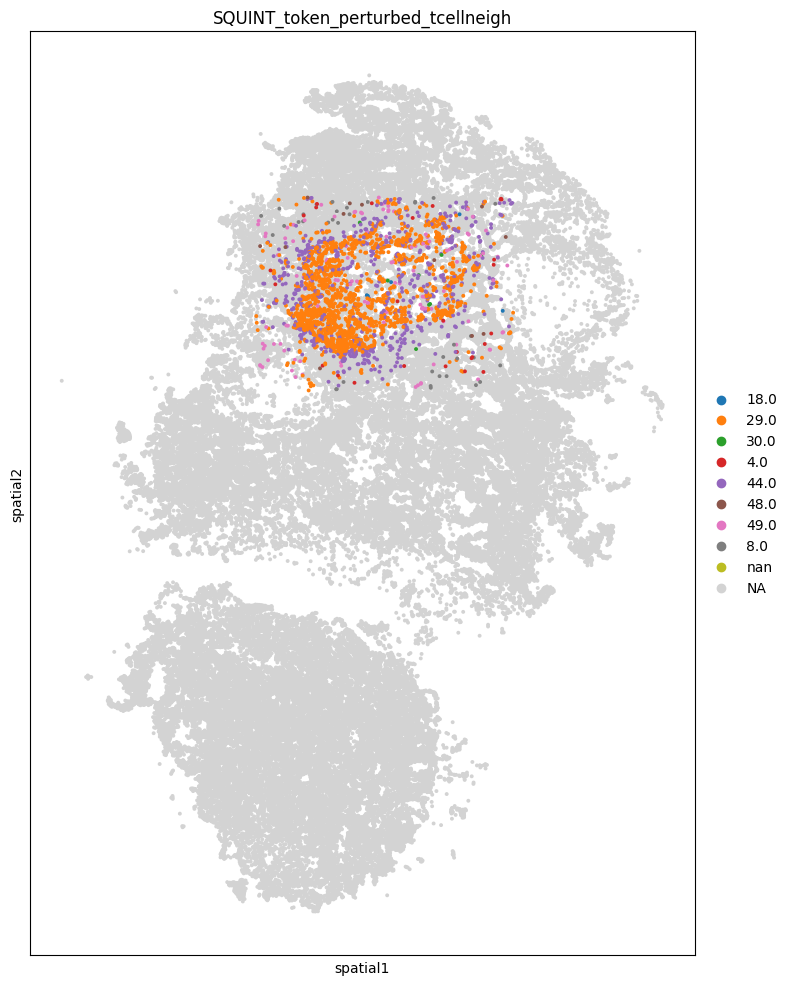

In [523]:
# Visualize tokens
plt.rcParams["figure.figsize"] = (12, 12)
try:
    del(adata_batch_squint.uns['SQUINT_token_perturbed_tcellneigh_colors'])
except:
    pass

sc.pl.spatial(adata_batch_squint,
              color='SQUINT_token_perturbed_tcellneigh',
              spot_size=30)

## Compare unperturbed vs perturbed

In [524]:
props = adata_batch_squint[adata_batch_squint.obs['macrophage_with_tcell_neighbors']].obs['SQUINT_token'].value_counts(normalize=True)

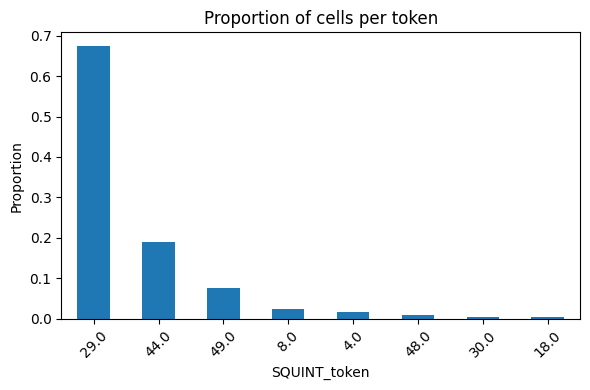

In [525]:
plt.figure(figsize=(6,4))
props.plot(kind="bar")

plt.ylabel("Proportion")
plt.xlabel("SQUINT_token")
plt.title("Proportion of cells per token")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [526]:
props_pert = adata_batch_squint[adata_batch_squint.obs['macrophage_with_tcell_neighbors']].obs['SQUINT_token_perturbed'].value_counts(normalize=True)

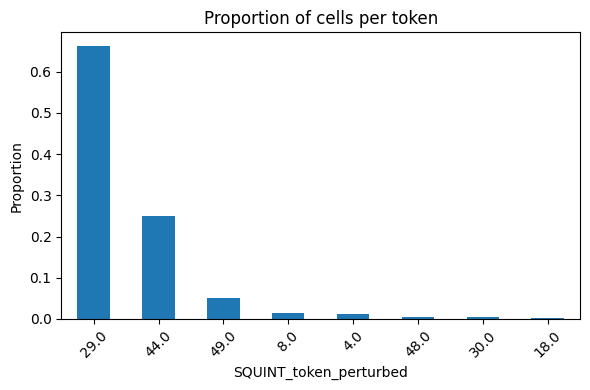

In [527]:
plt.figure(figsize=(6,4))
props_pert.plot(kind="bar")

plt.ylabel("Proportion")
plt.xlabel("SQUINT_token_perturbed")
plt.title("Proportion of cells per token")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


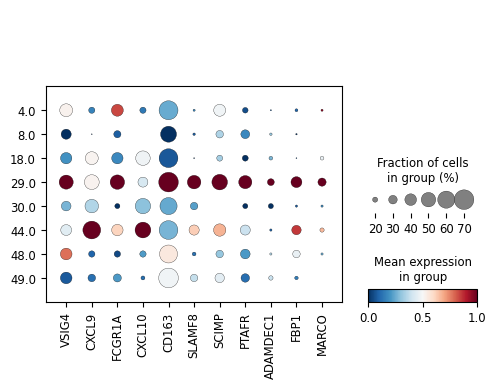

In [408]:
# Visualize gene expression dotplot per token
sc.pl.dotplot(
    adata_batch_squint,
    var_names=hvg_icb_genes,
    groupby="SQUINT_token",
    standard_scale="var",   # scales per gene (optional, for better comparability)
    dot_max=0.7,            # max dot size
    dot_min=0.1,            # min dot size
    color_map="RdBu_r"      # diverging colormap
)

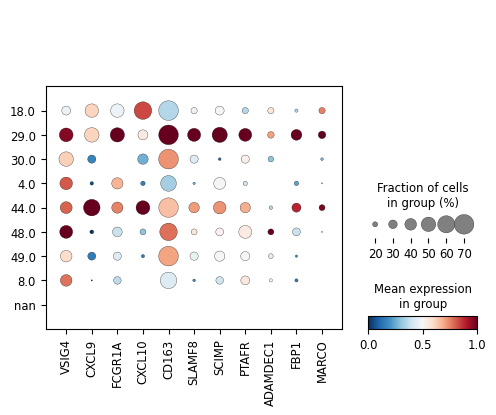

In [462]:
# Visualize gene expression dotplot per token
sc.pl.dotplot(
    adata_batch_squint,
    var_names=hvg_icb_genes,
    groupby="SQUINT_token_perturbed",
    standard_scale="var",   # scales per gene (optional, for better comparability)
    dot_max=0.7,            # max dot size
    dot_min=0.1,            # min dot size
    color_map="RdBu_r"      # diverging colormap
)

In [410]:
only_in_unperturbed = set(unique_tokens) - set(unique_tokens_perturbed)
print(only_in_unperturbed)

{4.0, 8.0, 44.0, 48.0, 49.0, 18.0, nan, 29.0, 30.0}


In [411]:
only_in_perturbed = set(unique_tokens_perturbed) - set(unique_tokens)
print(only_in_perturbed)

{'8.0', nan, '49.0', '30.0', '29.0', 'nan', '44.0', '48.0', '18.0', '4.0'}


In [412]:
# 4 -> 44
# 8 -> 29
# 29 -> 44
# 44 -> 29
# 49 -> 29

In [413]:
ct = pd.crosstab(
    adata_batch_squint.obs["SQUINT_token"],
    adata_batch_squint.obs["SQUINT_token_perturbed"]
)
ct

SQUINT_token_perturbed,18.0,29.0,30.0,4.0,44.0,48.0,49.0,8.0
SQUINT_token,,,,,,,,
4.0,0,8,0,33,18,0,0,0
8.0,0,14,0,6,4,1,1,75
18.0,11,3,2,0,0,1,1,0
29.0,0,1684,0,0,185,0,9,0
30.0,0,3,8,1,3,0,0,0
44.0,0,88,0,0,413,1,3,0
48.0,0,8,1,0,5,15,0,0
49.0,2,47,2,1,23,0,207,3


In [148]:
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook"   # or "notebook_connected"

import pandas as pd
import plotly.graph_objects as go

# Build contingency table
ct = pd.crosstab(
    adata_batch_squint.obs["SQUINT_token"],
    adata_batch_squint.obs["SQUINT_token_perturbed"]
)

# Convert to long format
df_long = ct.stack().reset_index()
df_long.columns = ["source", "target", "value"]
df_long = df_long[df_long["value"] > 0]

# Ensure source/target are strings (avoids categorical/int issues in Sankey labels)
df_long["source"] = df_long["source"].astype(str)
df_long["target"] = df_long["target"].astype(str)

# Build label lists
sources = sorted(df_long["source"].unique().tolist())
targets = sorted(df_long["target"].unique().tolist())
labels = sources + targets

# Map to ids
label_to_id = {label: i for i, label in enumerate(labels)}

# Map sources/targets to numeric ids
df_long["source_id"] = df_long["source"].map(label_to_id).astype(int)
df_long["target_id"] = df_long["target"].map(label_to_id).astype(int) + len(sources)

# Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels
    ),
    link=dict(
        source=df_long["source_id"],
        target=df_long["target_id"],
        value=df_long["value"]
    )
)])

fig.update_layout(
    title_text="Flow of cells: SQUINT_token → SQUINT_token_perturbed",
    font_size=12
)

import plotly.io as pio
pio.renderers.default = "notebook"  # or "browser" if in script
fig.show()



In [ ]:
adata_batch_squint.obs['SQUINT_token']

In [ ]:
sc.pl.spatial(adata_batch_squint,
              color='SQUINT_token',
              spot_size=30)

In [ ]:
X_perturbed = torch.tensor(
    adata_batch_squint.layers['X_perturbed'], device=model.device)
X_perturbed_roi = X_perturbed[macrophage_roi_mask]

In [ ]:
X_perturbed_roi.shape

In [ ]:
xhat

In [ ]:
adata_batch_squint.uns['X_hat_perturbed'].shape

## Miscellaneous